# Classifying Particles with a Convolutional Neural Network


<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/Leolinen/TIF360/blob/main/HW2/particles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

In [96]:
!pip install deeplay  # Uncomment if using Colab/Kaggle.

In [97]:
import pickle
import torch
import torch.utils.data
import matplotlib.pyplot as plt
import numpy as np
import deeplay as dl
import torchmetrics as tm
from torch.nn.functional import relu
from skimage.exposure import rescale_intensity
from skimage.transform import resize


## Loading the Particle Dataset


In [98]:
with open("simple_particle_dataset.pkl", "rb") as f:
    raw = pickle.load(f)


class ParticleDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels):
        self.images = [
            torch.tensor(img, dtype=torch.float32).unsqueeze(0)
            for img in images
        ]
        self.labels = [
            torch.tensor(float(lbl[0]), dtype=torch.float32).unsqueeze(-1)
            for lbl in labels
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


dataset = ParticleDataset(raw["images"], raw["labels"])


### Splitting the Dataset and Defining the Data Loaders

In [99]:
train, test = torch.utils.data.random_split(dataset, [0.8, 0.2])

... and define the data loaders.

In [100]:
train_loader = torch.utils.data.DataLoader(train, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test, batch_size=256, shuffle=False)

### Plotting the ROC Curve

Implement a function to plot the ROC curve ...

In [101]:
def plot_roc(classifier, loader):
    """Plot ROC curve."""
    roc = tm.ROC(task="binary")
    f1 = tm.F1Score(task="binary")
    for image, label in loader:
        preds = classifier(image)
        roc.update(preds, label.long())
        f1.update(preds, label.long())

    fig, ax = roc.plot(score=True)
    ax.grid(False)
    ax.axis("square")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="center right")
    plt.show()

    print(f"F1 Score: {f1.compute():.4f}")


## Classifying the Particles with Convolutional Neural Networks

Implement a convolutional neural network with a dense top ...

In [120]:
conv_base = dl.ConvolutionalNeuralNetwork(
    in_channels=1, hidden_channels=[16, 16], out_channels=16,
)
conv_base.blocks[2].pool.configure(torch.nn.MaxPool2d, kernel_size=10)

connector = dl.Layer(torch.nn.AdaptiveAvgPool2d, output_size=1)

dense_top = dl.MultiLayerPerceptron(
    in_features=16, hidden_features=[], out_features=1,
    out_activation=torch.nn.Sigmoid,
)

cnn = dl.Sequential(conv_base, connector, dense_top)


... print out its detailed architecture ...

In [103]:
print(cnn)

Sequential(
  (0): ConvolutionalNeuralNetwork(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): Layer[Conv2d](in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
      (1): Conv2dBlock(
        (layer): Layer[Conv2d](in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
      (2): Conv2dBlock(
        (pool): Layer[MaxPool2d](kernel_size=4)
        (layer): Layer[Conv2d](in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1)
        (activation): Layer[Identity]()
      )
    )
  )
  (1): Layer[AdaptiveAvgPool2d](output_size=1)
  (2): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Layer[Linear](in_features=16, out_features=1, bias=True)
        (activation): Layer[Sigmoid]()
      )
    )
  )
)


... compile it ...

In [121]:
cnn_classifier = dl.BinaryClassifier(
    model=cnn, optimizer=dl.RMSprop(lr=0.00001),
).create()

... and print out the compiled convolutional neural network.

In [105]:
print(cnn_classifier)

BinaryClassifier(
  (loss): BCELoss()
  (train_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (BinaryAccuracy): BinaryAccuracy(),
    prefix=test
  )
  (model): Sequential(
    (0): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (layer): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): Identity()
        )
      )
    )
    (1): AdaptiveAvgP

### Training the Convolutional Neural Network

In [122]:
cnn_trainer = dl.Trainer(max_epochs=5, accelerator="auto")
cnn_trainer.fit(cnn_classifier, train_loader)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ BCELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │  4.8 K │ train │     0 │
│ 5 │ optimizer     │ RMSprop          │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 4.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 27                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

### Testing the Convolutional Neural Network

In [123]:
cnn_trainer.test(cnn_classifier, test_loader)

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testBinaryAccuracy_epoch  │    0.9810000061988831     │
│      test_loss_epoch      │    0.49176937341690063    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 0.49176937341690063,
  'testBinaryAccuracy_epoch': 0.9810000061988831}]

### Plotting the ROC Curve

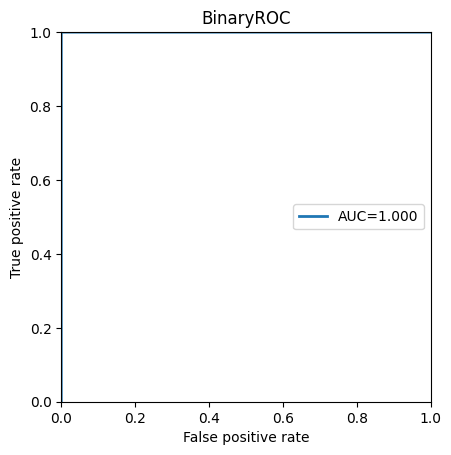

F1 Score: 0.9803


In [124]:
plot_roc(cnn_classifier, test_loader)

## Extra

### Checking the Values of the Filters

The following code accesses the 32nd filter's weights in the first convolutional layer of the CNN. It navigates through the model's first module (`model[0]`), selects the initial block (`blocks[0]`), and then targets the layer's weights (`layer.weight[15]`).

In [109]:
filter = cnn_classifier.model[0].blocks[0].layer.weight[15]

print(filter)

tensor([[[-0.3098,  0.2192, -0.2720],
         [-0.1481, -0.0188, -0.3007],
         [-0.3602,  0.2401, -0.1933]]], grad_fn=<SelectBackward0>)


### Visualizing the Activations of the Convolutional Layers

Pick the image of an particle to then check the activations it produces on the last convolutional layer ...

In [110]:
im_ind = 0
image, label = dataset[im_ind]
image_hr = image[0].numpy()  # (64, 64) grayscale


... verify whether this image is of a particle ...

In [111]:
print(label)


tensor([1.])


... define a function to visualize the activations ...

In [112]:
def plot_activations(activations, cols=8):
    """Visualize activations."""
    rows = -(activations.shape[0] // -cols)

    fig, axs = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
    for i, ax in enumerate(axs.ravel()):
        ax.axis("off")
        if i < activations.shape[0]:
            ax.imshow(activations[i].numpy())
            ax.set_title(i, fontsize=16)
    plt.show()

... add a hook to access the activations in the forward pass ...


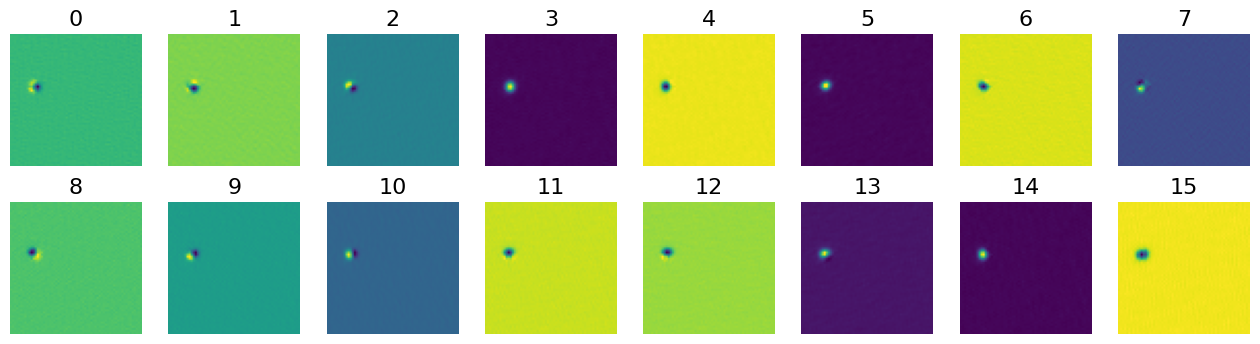

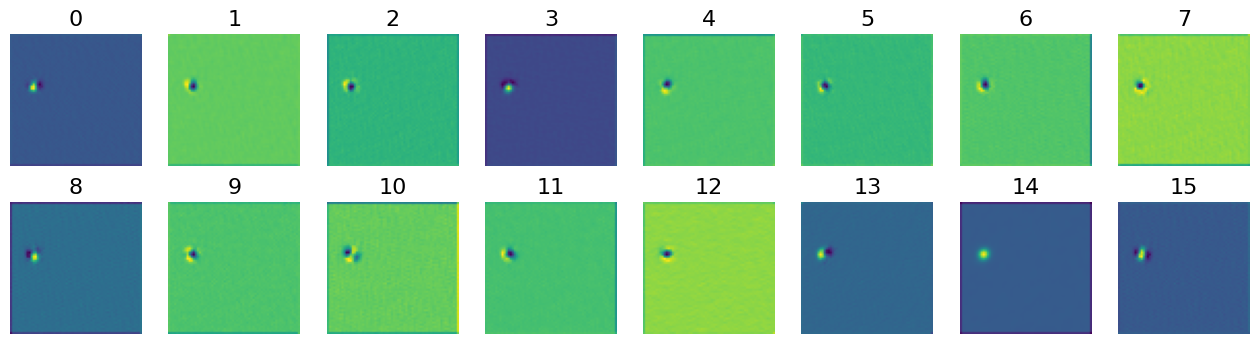

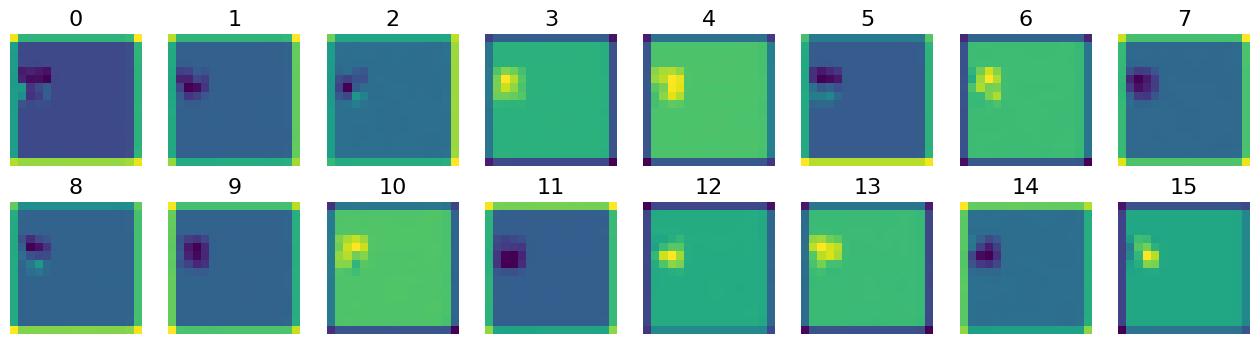

In [113]:
def hook_func(layer, input, output):
    """Hook for activations."""
    activations = output.detach().clone()
    plot_activations(activations[0])

for block in cnn_classifier.model[0].blocks:
    layer = block.layer
    handle_hook = layer.register_forward_hook(hook_func)

    try:
        pred = cnn_classifier.model(image.unsqueeze(0))
    except Exception as e:
        print(f"An error occurred during model prediction: {e}")
    finally:
        handle_hook.remove()

### Visualizing the Heatmaps

Use hooks to keep tracks also of the gradients in the backward pass ...

In [114]:
hookdata = {}

def fwd_hook_func(layer, input, output):
    """Forward hook function."""
    hookdata["activations"] = output.detach().clone()

def bwd_hook_func(layer, grad_input, grad_output):
    """Backward hook function."""
    hookdata["gradients"] = grad_output[0].detach().clone()

layer = cnn_classifier.model[0].blocks[3].layer
handle_fwd_hook = layer.register_forward_hook(fwd_hook_func)
handle_bwd_hook = layer.register_full_backward_hook(bwd_hook_func)

try:
    pred = cnn_classifier.model(image.unsqueeze(0))
    pred.sum().backward()
except Exception as e:
    print(f"An error occurred during model prediction: {e}")
finally:
    handle_fwd_hook.remove()
    handle_bwd_hook.remove()

IndexError: index 3 is out of range

... calculate the heatmap combining activations and gradients ...

In [ ]:
activations = hookdata["activations"][0]
gradients = hookdata["gradients"][0]

pooled_gradients = gradients.mean(dim=[1, 2], keepdim=True)
heatmap = relu((pooled_gradients * activations).sum(0)).detach().numpy()


... and plot the heatmap.

In [ ]:
rescaled_image = rescale_intensity(image_hr, out_range=(0, 1))
resized_heatmap = resize(heatmap, rescaled_image.shape, order=2)
rescaled_heatmap = rescale_intensity(resized_heatmap, out_range=(0.25, 1))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rescaled_image, cmap="gray", interpolation="bilinear")
plt.title("Original image", fontsize=16)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(rescaled_heatmap, interpolation="bilinear")
plt.title("Heatmap with Grad-CAM", fontsize=16)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rescaled_image * rescaled_heatmap, cmap="gray", interpolation="bilinear")
plt.title("Overlay", fontsize=16)
plt.axis("off")

plt.show()
